# Spectral and Wavelet Features

**Docker image**: `ml4t`

This notebook demonstrates frequency-domain feature engineering:
wavelet decomposition for multi-resolution analysis, rolling FFT for
production spectral features, and Welch's method for robust power
spectral density estimation.

**Learning Objectives**:
- Decompose returns into frequency components via wavelets (research tool)
- Compute rolling FFT features: spectral energy, dominant frequency, entropy
- Estimate power spectral density with Welch's method
- Build a rolling spectral heatmap for time-frequency visualization
- Compute `low_freq_ratio` as a regime-sensitive feature

**Book Reference**: Chapter 9, Section 9.2 (Signal Transforms and Spectral Features)

**Prerequisites**: `01_visual_diagnostics` for stationarity concepts.

In [1]:
"""Spectral and Wavelet Features — frequency-domain feature engineering."""

import importlib
import warnings
from typing import Any, cast

warnings.filterwarnings("ignore")

from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display
from ml4t.engineer.features.ml import fourier_features, rolling_entropy
from scipy.signal import welch

from data import load_etfs

pywt = cast(Any, importlib.import_module("pywt"))

In [2]:
# Production defaults — Papermill injects overrides for CI
START_DATE = "2015-01-01"
END_DATE = "2024-12-31"

## Load Data

SPY returns provide a stationary signal suitable for spectral analysis.

In [3]:
etfs = load_etfs(symbols=["SPY"])
spy = etfs.select(["timestamp", "close"]).sort("timestamp")

START = datetime.strptime(START_DATE, "%Y-%m-%d")
END = datetime.strptime(END_DATE, "%Y-%m-%d")
spy = spy.filter((pl.col("timestamp") >= START) & (pl.col("timestamp") <= END))

spy = spy.with_columns(returns=pl.col("close").pct_change()).drop_nulls()

spy_pd = spy.to_pandas().set_index("timestamp")
returns = spy_pd["returns"].to_numpy(dtype=float, copy=True)
prices = spy_pd["close"].to_numpy(dtype=float, copy=True)
dates = spy_pd.index

print(f"SPY: {len(spy_pd):,} obs ({dates.min().date()} to {dates.max().date()})")

SPY: 2,515 obs (2015-01-05 to 2024-12-31)


---

# Part 1: Wavelet Analysis (Offline Research Tool)

Wavelets provide **multi-resolution analysis** — they reveal what time horizons
carry signal vs noise. This is an **analysis tool**, not a production feature
generator: standard DWT is non-causal (uses the entire series).

**Key insight**: Use wavelet analysis to understand scale relationships, then
translate those insights into simpler **causal proxies** (rolling averages,
filters).

### Wavelet Families for Financial Data

Different wavelet families offer different trade-offs:

| Family | Key Property | Best For |
|--------|-------------|----------|
| `db6` (Daubechies 6) | Good time-frequency localization | General purpose |
| `sym6` (Symlet 6) | Near-symmetric, reduces phase distortion | Trend analysis |
| `coif3` (Coiflet 3) | Near-zero moments, good reconstruction | Feature design |

In [4]:
families = pywt.families()
print("Available wavelet families:", families)
print()
for name, wname in [("Daubechies-6", "db6"), ("Symlet-6", "sym6"), ("Coiflet-3", "coif3")]:
    w = pywt.Wavelet(wname)
    print(f"  {name:15s} ({wname}): filter length={w.dec_len}, vanishing moments={w.dec_len // 2}")

Available wavelet families: ['haar', 'db', 'sym', 'coif', 'bior', 'rbio', 'dmey', 'gaus', 'mexh', 'morl', 'cgau', 'shan', 'fbsp', 'cmor']

  Daubechies-6    (db6): filter length=12, vanishing moments=6
  Symlet-6        (sym6): filter length=12, vanishing moments=6
  Coiflet-3       (coif3): filter length=18, vanishing moments=9


### Multi-Resolution Decomposition

Decompose returns into approximation (trend) and detail (fluctuation)
components at increasing time scales.

In [5]:
def wavelet_decompose(
    signal: np.ndarray,
    wavelet: str = "db6",
    level: int = 5,
) -> dict[str, np.ndarray]:
    """Decompose signal into approximation and detail components.

    WARNING: Non-causal — uses entire series. For analysis only.
    """
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    result = {}

    # Approximation (lowest frequency / trend)
    approx = pywt.upcoef("a", coeffs[0], wavelet, level=level, take=len(signal))
    result[f"A{level}"] = approx

    # Details (higher frequencies)
    for i, detail in enumerate(coeffs[1:], 1):
        d = pywt.upcoef("d", detail, wavelet, level=level - i + 1, take=len(signal))
        result[f"D{level - i + 1}"] = d

    return result

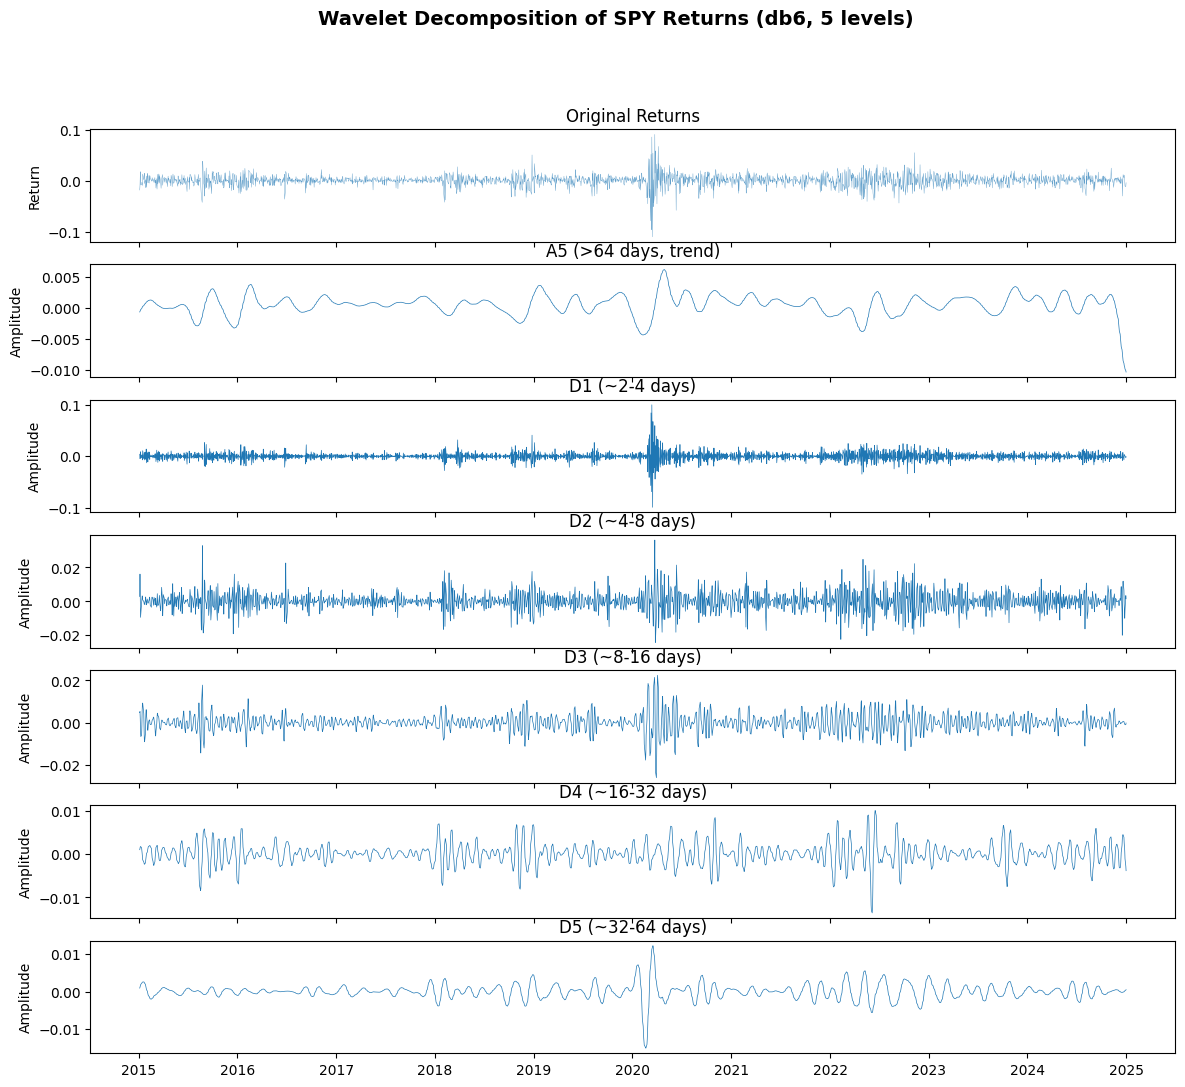

In [6]:
decomp = wavelet_decompose(returns, wavelet="db6", level=5)

fig, axes = plt.subplots(len(decomp) + 1, 1, figsize=(14, 12), sharex=True)

axes[0].plot(dates, returns, linewidth=0.3, alpha=0.7)
axes[0].set_title("Original Returns")
axes[0].set_ylabel("Return")

scale_labels = {
    "D1": "D1 (~2-4 days)",
    "D2": "D2 (~4-8 days)",
    "D3": "D3 (~8-16 days)",
    "D4": "D4 (~16-32 days)",
    "D5": "D5 (~32-64 days)",
    "A5": "A5 (>64 days, trend)",
}

for i, name in enumerate(sorted(decomp.keys()), 1):
    axes[i].plot(dates, decomp[name], linewidth=0.5)
    label = scale_labels.get(name, name)
    axes[i].set_title(label)
    axes[i].set_ylabel("Amplitude")

plt.suptitle("Wavelet Decomposition of SPY Returns (db6, 5 levels)", fontsize=14, fontweight="bold")
plt.show()

### Scale Variance Analysis

Which time scales contain the most variance (and potentially signal)?

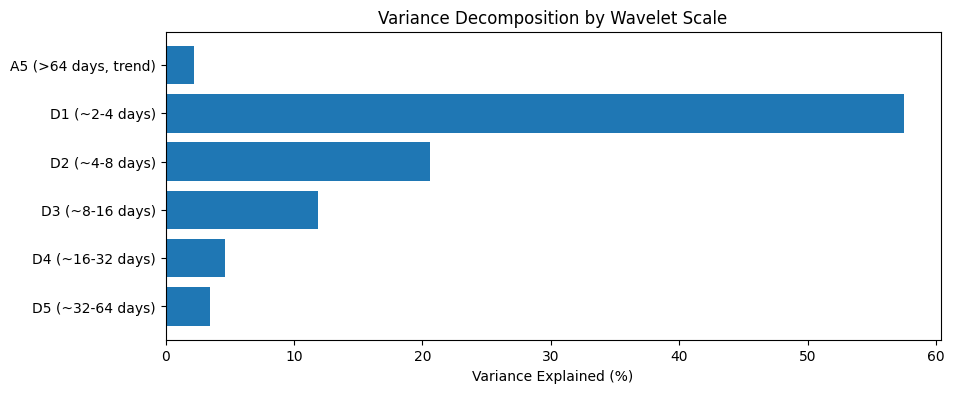

In [7]:
total_var = np.var(returns)

scale_names = []
scale_pcts = []
for name in sorted(decomp.keys()):
    var = np.var(decomp[name])
    pct = 100 * var / total_var
    scale_names.append(scale_labels.get(name, name))
    scale_pcts.append(pct)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(scale_names, scale_pcts)
ax.set_xlabel("Variance Explained (%)")
ax.set_title("Variance Decomposition by Wavelet Scale")
ax.invert_yaxis()
plt.show()

### Wavelet Family Comparison

Compare how db6, sym6, and coif3 decompose the same signal.

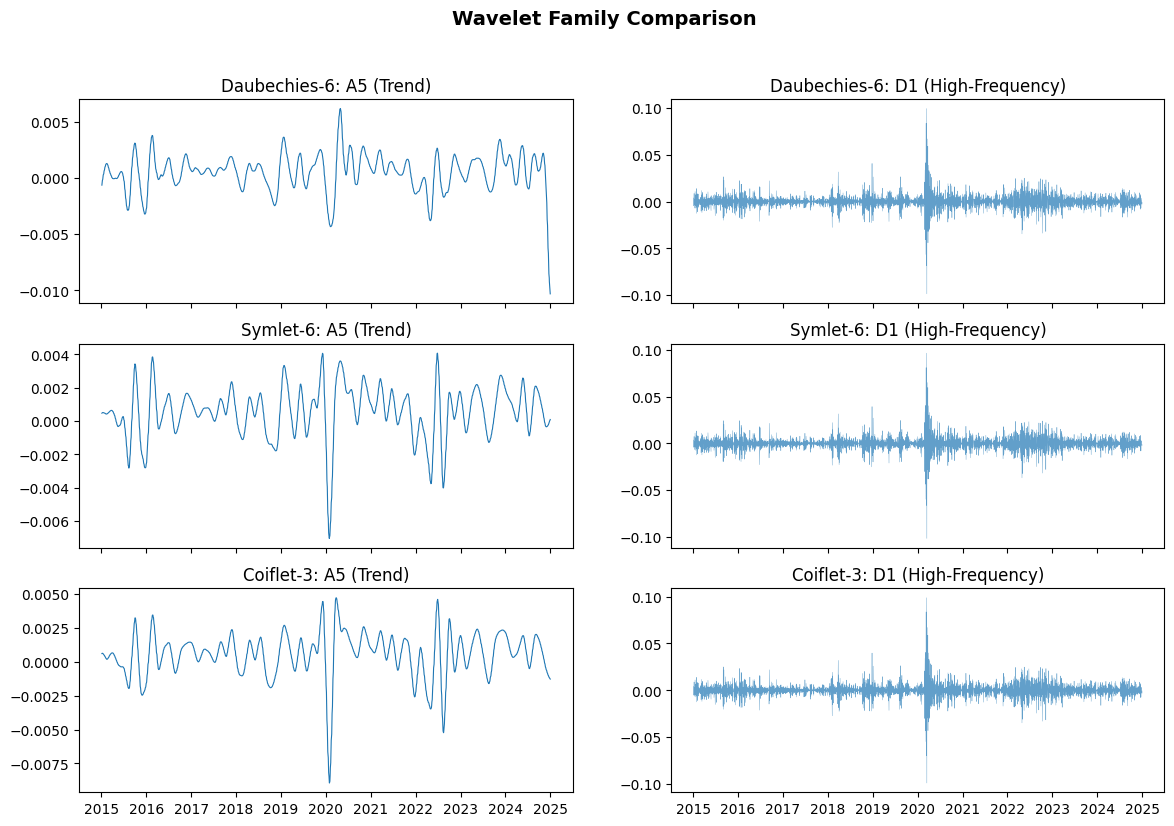

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)

for row, (wname, label) in enumerate(
    [("db6", "Daubechies-6"), ("sym6", "Symlet-6"), ("coif3", "Coiflet-3")]
):
    dec = wavelet_decompose(returns, wavelet=wname, level=5)

    # Show A5 (trend) and D1 (noise)
    axes[row, 0].plot(dates, dec["A5"], linewidth=0.8)
    axes[row, 0].set_title(f"{label}: A5 (Trend)")

    axes[row, 1].plot(dates, dec["D1"], linewidth=0.3, alpha=0.7)
    axes[row, 1].set_title(f"{label}: D1 (High-Frequency)")

plt.suptitle("Wavelet Family Comparison", fontsize=14, fontweight="bold")
plt.show()

**Finding**: The three wavelet families produce nearly identical trend components
(A5) but differ in high-frequency detail (D1). Daubechies-6 (`db6`) is the
recommended default — it provides the best balance of time-frequency localization
for financial data. The choice of wavelet family matters far less than the choice
of decomposition level.

### Scale Insights → Causal Proxies

Production features must be causal. Translate wavelet scale insights into
rolling window features:

| Wavelet Scale | Time Horizon | Causal Proxy |
|---------------|-------------|--------------|
| D1 | 2-4 days | 3-day rolling features |
| D2 | 4-8 days | 5-day rolling features |
| D3 | 8-16 days | 10-day rolling features |
| D4 | 16-32 days | 21-day rolling features |
| D5 | 32-64 days | 63-day rolling features |
| A5 | >64 days | 126-day rolling features |

In [9]:
scale_to_window = {"D1": 3, "D2": 5, "D3": 10, "D4": 21, "D5": 63, "A5": 126}

proxy_results = {}
for scale, window in scale_to_window.items():
    # Rolling volatility as causal proxy for scale energy
    vol = np.full(len(returns), np.nan)
    for t in range(window, len(returns)):
        vol[t] = np.std(returns[t - window : t])
    proxy_results[f"vol_{window}d"] = vol

    # Compare with wavelet scale energy
    wavelet_energy = np.abs(decomp[scale])
    # Rolling mean of wavelet energy
    wav_roll = np.full(len(returns), np.nan)
    for t in range(window, len(returns)):
        wav_roll[t] = np.mean(wavelet_energy[t - window : t])
    proxy_results[f"wav_energy_{scale}"] = wav_roll

# Show correlation between causal proxy and wavelet energy
proxy_corr_rows = []
for scale, window in scale_to_window.items():
    vol = proxy_results[f"vol_{window}d"]
    wav = proxy_results[f"wav_energy_{scale}"]
    mask = ~np.isnan(vol) & ~np.isnan(wav)
    if mask.sum() > 50:
        corr = np.corrcoef(vol[mask], wav[mask])[0, 1]
        proxy_corr_rows.append({"scale": scale, "rolling_window_days": window, "correlation": corr})

display(pd.DataFrame(proxy_corr_rows))

,scale,rolling_window_days,correlation
0,D1,3,0.901598
1,D2,5,0.631485
2,D3,10,0.710901
3,D4,21,0.418161
4,D5,63,0.787108
5,A5,126,0.781413


---

# Part 2: Rolling FFT Features (Production)

Fourier analysis decomposes time series into frequency components, revealing
periodic structure invisible in the time domain. **Rolling FFT** provides
production-ready causal features.

### Rolling FFT Implementation

For each rolling window, compute the FFT and extract features from the
power spectrum.

In [10]:
def rolling_fft_features(
    signal: np.ndarray,
    window: int = 63,
    target_periods: list[int] | None = None,
) -> dict[str, np.ndarray]:
    """Compute spectral features using rolling FFT.

    Features extracted:
    - spectral_energy: Total power (excluding DC)
    - dominant_period: Period of peak frequency (in samples)
    - spectral_entropy: Entropy of normalized power spectrum
    - low_freq_ratio: Fraction of energy in periods longer than window/3
      (frequencies below 3/window cycles/sample — the slowest resolvable
      oscillations, well-defined for every window length)
    - energy at target periods: Power near specific calendar frequencies
    """
    if target_periods is None:
        target_periods = [5, 21, 63]

    n = len(signal)
    spectral_energy = np.full(n, np.nan)
    dominant_period = np.full(n, np.nan)
    spectral_entropy = np.full(n, np.nan)
    low_freq_ratio = np.full(n, np.nan)
    valid = np.zeros(n, dtype=bool)
    freq_energies = {p: np.full(n, np.nan) for p in target_periods}

    for t in range(window, n):
        segment = signal[t - window : t]

        # Detrend (remove mean)
        segment = segment - segment.mean()

        # FFT
        fft_vals = np.fft.rfft(segment)
        power = np.abs(fft_vals) ** 2
        freqs = np.fft.rfftfreq(window)

        # Total spectral energy (excluding DC)
        total_power = np.sum(power[1:])
        spectral_energy[t] = total_power

        # Dominant period
        if len(power) > 1 and total_power > 0:
            dom_idx = np.argmax(power[1:]) + 1
            if freqs[dom_idx] > 0:
                dominant_period[t] = 1.0 / freqs[dom_idx]

        # Spectral entropy
        if total_power > 0:
            p_norm = power[1:] / total_power
            p_norm = p_norm[p_norm > 0]
            spectral_entropy[t] = -np.sum(p_norm * np.log(p_norm))

        # Low-frequency ratio: energy in the slowest resolvable oscillations,
        # defined window-relative as periods longer than window/3 (freq < 3/window).
        # This band is non-degenerate for every window; at window=63 it coincides
        # with the monthly cutoff 1/21.
        low_mask = (freqs > 0) & (freqs < 3.0 / window)
        if low_mask.any() and total_power > 0:
            low_freq_ratio[t] = np.sum(power[low_mask]) / total_power

        # Energy at target periods
        for tp in target_periods:
            target_freq = 1.0 / tp
            freq_idx = np.argmin(np.abs(freqs - target_freq))
            low_idx = max(1, freq_idx - 1)
            high_idx = min(len(power), freq_idx + 2)
            freq_energies[tp][t] = np.sum(power[low_idx:high_idx])

        valid[t] = True

    result = {
        "spectral_energy": spectral_energy,
        "dominant_period": dominant_period,
        "spectral_entropy": spectral_entropy,
        "low_freq_ratio": low_freq_ratio,
        "valid": valid,
    }
    for tp, energy in freq_energies.items():
        result[f"energy_period_{tp}"] = energy

    return result

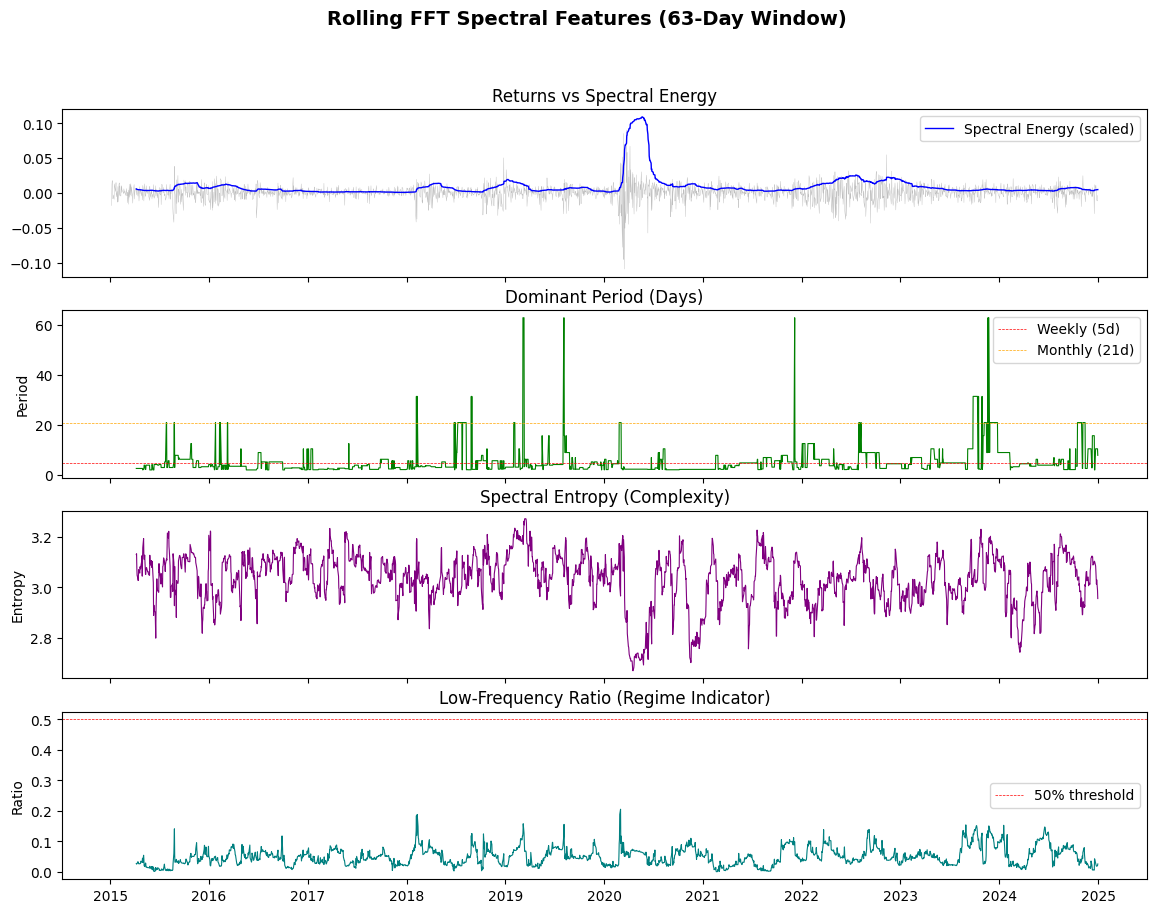

In [11]:
fft_out = rolling_fft_features(returns, window=63, target_periods=[5, 21, 63])

valid_mask = fft_out["valid"]
valid_dates = dates[valid_mask]

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

ax = axes[0]
ax.plot(dates, returns, linewidth=0.3, alpha=0.5, color="gray")
energy_scaled = fft_out["spectral_energy"][valid_mask]
energy_scaled = energy_scaled / energy_scaled.max() * np.abs(returns).max()
ax.plot(valid_dates, energy_scaled, linewidth=1, color="blue", label="Spectral Energy (scaled)")
ax.set_title("Returns vs Spectral Energy")
ax.legend()

ax = axes[1]
ax.plot(valid_dates, fft_out["dominant_period"][valid_mask], linewidth=0.8, color="green")
ax.axhline(5, color="red", linestyle="--", linewidth=0.5, label="Weekly (5d)")
ax.axhline(21, color="orange", linestyle="--", linewidth=0.5, label="Monthly (21d)")
ax.set_title("Dominant Period (Days)")
ax.set_ylabel("Period")
ax.legend()

ax = axes[2]
ax.plot(valid_dates, fft_out["spectral_entropy"][valid_mask], linewidth=0.8, color="purple")
ax.set_title("Spectral Entropy (Complexity)")
ax.set_ylabel("Entropy")

ax = axes[3]
ax.plot(valid_dates, fft_out["low_freq_ratio"][valid_mask], linewidth=0.8, color="teal")
ax.axhline(0.5, color="red", linestyle="--", linewidth=0.5, label="50% threshold")
ax.set_title("Low-Frequency Ratio (Regime Indicator)")
ax.set_ylabel("Ratio")
ax.legend()

plt.suptitle("Rolling FFT Spectral Features (63-Day Window)", fontsize=14, fontweight="bold")
plt.show()

### Calendar-Cycle Detection

Compare energy at weekly, monthly, and quarterly frequencies to detect
periodic patterns.

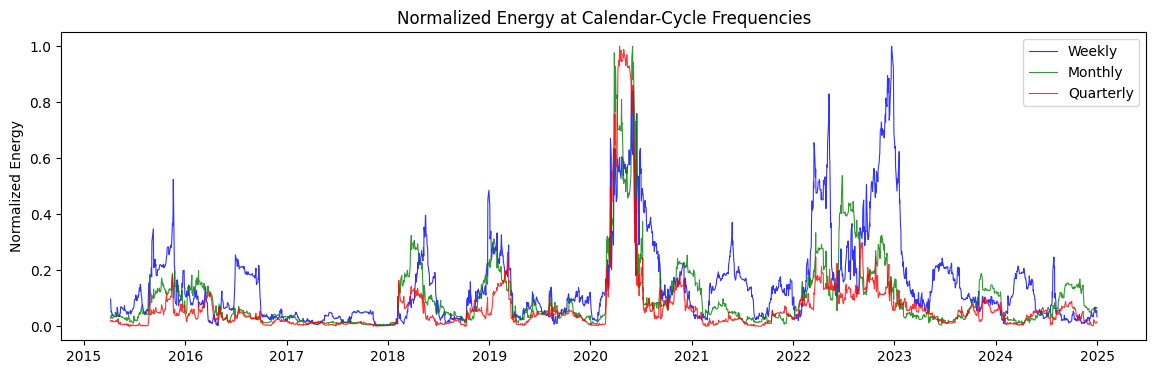

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))

for tp, color, label in [(5, "blue", "Weekly"), (21, "green", "Monthly"), (63, "red", "Quarterly")]:
    energy = fft_out[f"energy_period_{tp}"][valid_mask]
    energy_norm = energy / np.nanmax(energy)
    ax.plot(valid_dates, energy_norm, linewidth=0.8, color=color, label=label, alpha=0.8)

ax.set_title("Normalized Energy at Calendar-Cycle Frequencies")
ax.set_ylabel("Normalized Energy")
ax.legend()
plt.show()

---

# Part 3: Welch's Method (Robust PSD Estimation)

Welch's method averages periodograms over overlapping segments, reducing
variance at the cost of frequency resolution. It is more robust than a
single FFT for estimating the power spectral density (PSD).

### Full-Sample PSD

Compute the PSD of the entire return series to identify persistent
periodicities.

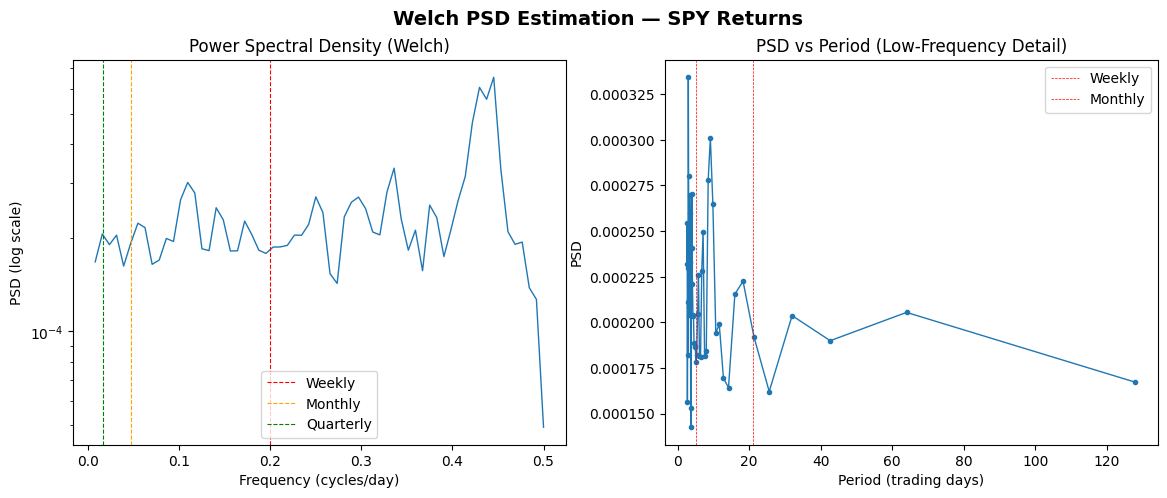

In [13]:
# Welch PSD of full return series
freqs_welch, psd_welch = welch(returns, fs=1.0, nperseg=128, noverlap=64)

# Convert frequency to period for interpretability
periods_welch = np.where(freqs_welch > 0, 1.0 / freqs_welch, np.inf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(freqs_welch[1:], psd_welch[1:], linewidth=1)
for freq, label, color in [
    (1 / 5, "Weekly", "red"),
    (1 / 21, "Monthly", "orange"),
    (1 / 63, "Quarterly", "green"),
]:
    ax.axvline(freq, color=color, linestyle="--", linewidth=0.8, label=label)
ax.set_xlabel("Frequency (cycles/day)")
ax.set_ylabel("PSD (log scale)")
ax.set_title("Power Spectral Density (Welch)")
ax.legend()

ax = axes[1]
ax.plot(periods_welch[1:50], psd_welch[1:50], linewidth=1, marker="o", markersize=3)
for period, label in [(5, "Weekly"), (21, "Monthly")]:
    ax.axvline(period, color="red", linestyle="--", linewidth=0.5, label=label)
ax.set_xlabel("Period (trading days)")
ax.set_ylabel("PSD")
ax.set_title("PSD vs Period (Low-Frequency Detail)")
ax.legend()

plt.suptitle("Welch PSD Estimation — SPY Returns", fontsize=14, fontweight="bold")
plt.show()

### Rolling Welch PSD

Compute Welch PSD in a rolling window to track how the spectral profile
changes over time.

In [14]:
def rolling_welch_psd(
    signal: np.ndarray,
    window: int = 252,
    step: int = 5,
    nperseg: int = 64,
) -> tuple[np.ndarray, Any, np.ndarray]:
    """Compute rolling Welch PSD.

    Returns (time_indices, frequencies, psd_matrix) where psd_matrix
    has shape (n_windows, n_freqs).
    """
    n = len(signal)
    time_indices = []
    psd_list = []
    freqs_out = None

    for end in range(window, n, step):
        segment = signal[end - window : end]
        f, pxx = welch(segment, fs=1.0, nperseg=min(nperseg, window // 2), noverlap=nperseg // 2)
        if freqs_out is None:
            freqs_out = f
        psd_list.append(pxx)
        time_indices.append(end)

    return np.array(time_indices), freqs_out, np.array(psd_list)

In [15]:
time_idx, freqs_w, psd_matrix = rolling_welch_psd(returns, window=252, step=5, nperseg=64)

### Time-Frequency Heatmap

A spectrogram-like visualization showing how spectral energy shifts over
time. Bright regions indicate periods with concentrated energy at a
particular frequency.

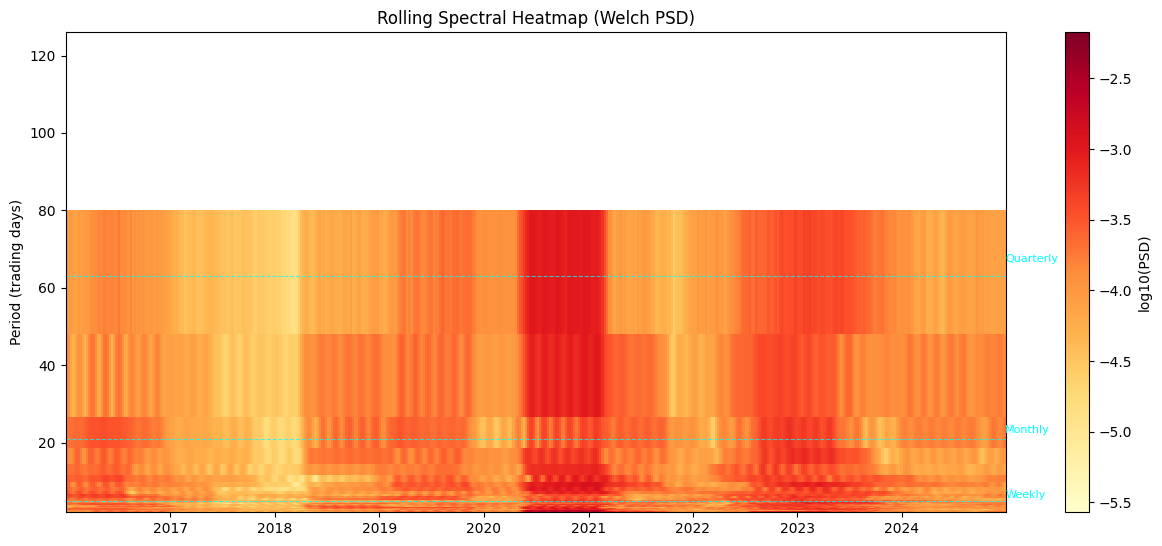

In [16]:
# Convert to periods for y-axis, cap at 126 days
period_mask = freqs_w > 1.0 / 126  # Only show periods up to 126 days
freqs_plot = freqs_w[period_mask]
periods_plot = 1.0 / freqs_plot
psd_plot = psd_matrix[:, period_mask]

fig, ax = plt.subplots(figsize=(14, 6))

# Log-scale PSD for better visibility
log_psd = np.log10(psd_plot.T + 1e-15)

im = ax.pcolormesh(
    dates[time_idx],
    periods_plot,
    log_psd,
    cmap="YlOrRd",
    shading="auto",
)

ax.set_ylabel("Period (trading days)")
ax.set_title("Rolling Spectral Heatmap (Welch PSD)")
ax.set_ylim(2, 126)

# Mark calendar frequencies
for period, label in [(5, "Weekly"), (21, "Monthly"), (63, "Quarterly")]:
    ax.axhline(period, color="cyan", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.text(dates[time_idx[-1]], period * 1.05, label, fontsize=8, color="cyan", va="bottom")

plt.colorbar(im, ax=ax, label="log10(PSD)")
fig.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.12)
plt.show()

---

# Part 4: Consolidated Feature Extraction

Combine spectral features from FFT and Welch into a single feature table
suitable for downstream ML.

### Multi-Window Spectral Features

Use multiple FFT window sizes to capture different frequency resolutions.

In [17]:
windows = [21, 63, 126]
all_features = {"timestamp": dates}

for w in windows:
    fft = rolling_fft_features(returns, window=w, target_periods=[5, 21])
    all_features[f"spectral_energy_{w}d"] = fft["spectral_energy"]
    all_features[f"spectral_entropy_{w}d"] = fft["spectral_entropy"]
    all_features[f"low_freq_ratio_{w}d"] = fft["low_freq_ratio"]
    all_features[f"dominant_period_{w}d"] = fft["dominant_period"]

feature_df = pl.DataFrame(all_features).drop_nulls()

print(f"Feature table: {len(feature_df):,} rows x {len(feature_df.columns)} columns")
feature_df.tail(10)

Feature table: 2,515 rows x 13 columns


timestamp,spectral_energy_21d,spectral_entropy_21d,low_freq_ratio_21d,dominant_period_21d,spectral_energy_63d,spectral_entropy_63d,low_freq_ratio_63d,dominant_period_63d,spectral_energy_126d,spectral_entropy_126d,low_freq_ratio_126d,dominant_period_126d
datetime[ms],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2024-12-17 00:00:00,0.005081,1.515583,0.128145,2.625,0.087087,3.099423,0.006088,15.75,0.54722,3.731928,0.010264,2.210526
2024-12-18 00:00:00,0.003302,1.437049,0.143374,2.625,0.087436,3.103386,0.006039,15.75,0.548744,3.722269,0.010235,2.210526
2024-12-19 00:00:00,0.01294,2.218999,0.184213,3.5,0.108805,3.102129,0.043085,2.032258,0.606564,3.737972,0.012866,2.210526
2024-12-20 00:00:00,0.012783,2.209917,0.219294,3.5,0.108669,3.098938,0.04089,2.032258,0.606379,3.736878,0.012621,2.210526
2024-12-23 00:00:00,0.014305,2.096074,0.162419,3.5,0.112661,3.084675,0.027778,10.5,0.613461,3.752602,0.009334,2.210526
2024-12-24 00:00:00,0.014375,2.100858,0.163372,3.5,0.113395,3.063638,0.024903,10.5,0.61456,3.749177,0.008957,2.210526
2024-12-26 00:00:00,0.015493,2.103643,0.205053,7.0,0.116441,3.012728,0.018775,10.5,0.621335,3.733628,0.007399,10.5
2024-12-27 00:00:00,0.015413,2.126209,0.177521,7.0,0.116167,3.029891,0.019208,10.5,0.621368,3.737056,0.00761,10.5
2024-12-30 00:00:00,0.016331,1.9074,0.086217,7.0,0.120047,2.989006,0.020156,10.5,0.627961,3.736797,0.008737,10.5


### Predictive Value of Spectral Features

Compute information coefficient (rank correlation with forward returns).

In [18]:
# Add forward returns
fwd_5d = np.full(len(returns), np.nan)
fwd_5d[:-5] = (prices[5:] - prices[:-5]) / prices[:-5]

fwd_df = pl.DataFrame({"timestamp": dates, "fwd_ret_5d": fwd_5d})
eval_df = feature_df.join(fwd_df, on="timestamp", how="inner").drop_nulls()

feature_cols = [c for c in eval_df.columns if c not in ("timestamp", "fwd_ret_5d")]
fwd = eval_df["fwd_ret_5d"].to_numpy()

ic_rows = []
for col in feature_cols:
    vals = eval_df[col].to_numpy()
    mask = np.isfinite(vals) & np.isfinite(fwd)
    if mask.sum() > 100:
        ic = np.corrcoef(vals[mask], fwd[mask])[0, 1]
        ic_rows.append({"feature": col, "ic_5d_fwd": ic, "n_obs": int(mask.sum())})

ic_df = pd.DataFrame(ic_rows).sort_values("ic_5d_fwd", key=lambda s: s.abs(), ascending=False)
display(ic_df)

,feature,ic_5d_fwd,n_obs
0,spectral_energy_21d,0.124894,2489
9,spectral_entropy_126d,-0.119901,2384
4,spectral_energy_63d,0.116821,2447
8,spectral_energy_126d,0.096430,2384
1,spectral_entropy_21d,-0.087200,2489
5,spectral_entropy_63d,-0.078243,2447
11,dominant_period_126d,-0.060637,2384
10,low_freq_ratio_126d,0.040230,2384
3,dominant_period_21d,-0.037207,2489
7,dominant_period_63d,0.007574,2447


## Feature Catalog: Spectral Features

| Feature | Source | Computation | Update |
|---------|--------|-------------|--------|
| `spectral_energy` | Rolling FFT | Total power (excl. DC) | Daily |
| `dominant_period` | Rolling FFT | Period of peak frequency | Daily |
| `spectral_entropy` | Rolling FFT | Normalized spectrum entropy | Daily |
| `low_freq_ratio` | Rolling FFT | Energy in periods longer than window/3 | Daily |
| `energy_period_5` | Rolling FFT | Power near weekly frequency | Daily |
| `energy_period_21` | Rolling FFT | Power near monthly frequency | Daily |

**Wavelet features** are for research only (non-causal). Translate scale
insights into rolling-window causal proxies.

## ml4t-engineer: Spectral and Entropy Features

The manual rolling FFT above requires ~30 lines of NumPy code per feature.
`ml4t-engineer` provides `fourier_features()` for spectral decomposition
and `rolling_entropy()` for information-theoretic features — both as
Polars expressions.

In [19]:
# Load SPY for ml4t-engineer demonstration
spy_ml4t = (
    etfs.filter(pl.col("symbol") == "SPY")
    .select(["timestamp", "close"])
    .sort("timestamp")
    .with_columns(returns=pl.col("close").pct_change())
    .drop_nulls()
)

# Fourier features capture periodic patterns
fourier_exprs = fourier_features("close", n_components=5)
spy_spectral = spy_ml4t.with_columns(**fourier_exprs)

# Rolling entropy measures predictability
spy_spectral = spy_spectral.with_columns(
    entropy=rolling_entropy("returns", window=50, n_bins=10),
)

print("=== ml4t-engineer: Spectral Features ===")
print(f"Fourier components: {len(fourier_exprs)} (sin/cos pairs for 5 harmonics)")
entropy_vals = spy_spectral["entropy"].drop_nulls()
print(f"Entropy: mean={entropy_vals.mean():.4f}, std={entropy_vals.std():.4f}")
print("  High entropy = unpredictable (efficient market)")
print("  Low entropy = patterned (potential signal)")

2026-07-12 23:06:45 | mlquant.features.rolling_entropy | INFO | [rolling_entropy] Starting calculation with parameters: window=50, n_bins=10 (shape: (7,))


2026-07-12 23:06:45 | mlquant.features.rolling_entropy | INFO | [rolling_entropy] Completed calculation (shape: (7,)) (0.03ms)


=== ml4t-engineer: Spectral Features ===
Fourier components: 10 (sin/cos pairs for 5 harmonics)
Entropy: mean=2.8087, std=0.2426
  High entropy = unpredictable (efficient market)
  Low entropy = patterned (potential signal)


`fourier_features()` generates sin/cos pairs at different frequencies,
capturing periodic structure in the price series. `rolling_entropy()`
quantifies the predictability of returns using Shannon entropy — a
complement to spectral energy that works in the information domain.

## Key Takeaways

1. **Wavelets are analysis tools**: Multi-resolution decomposition reveals
   which time scales carry signal, but DWT is non-causal — translate
   insights into rolling window proxies for production
2. **Rolling FFT provides production features**: `spectral_energy`,
   `dominant_period`, `spectral_entropy`, and `low_freq_ratio` are all
   causal and can update daily
3. **Welch's method is more robust**: Averaging over overlapping segments
   reduces variance in PSD estimates; use for full-sample analysis and
   time-frequency heatmaps
4. **`low_freq_ratio` is regime-sensitive**: High values indicate
   trend-dominated regimes; low values indicate noisy, mean-reverting
   markets — useful as a conditioning feature
5. **Multiple window sizes capture different scales**: 21-day (short-term),
   63-day (medium), 126-day (long-term) windows provide complementary
   frequency resolution

**Next**: See `06_path_signatures` for path-based features and
`07_arima_features` for time-domain forecasting features.